In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv', header=None, names=['X', 'Y', 'class'])

In [3]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


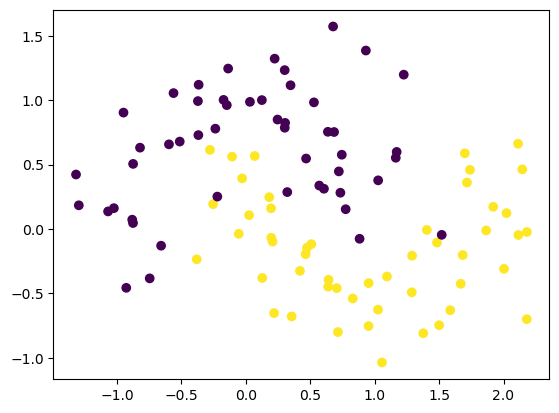

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

c:\Users\IRVINEi\miniconda3\envs\polynominal_regression\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[-1.0407662 , -1.1235021 , -0.45853117, -0.02682544,  0.07216068,
         -0.63612926, -1.6852851 ,  0.8505131 , -0.24476501, -0.01492913],
        [-1.3783509 , -1.4147539 ,  0.6736652 ,  0.63322276,  0.05142825,
          1.2709763 ,  0.35248744, -0.06672543, -2.2038982 , -0.7358227 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.03291504,  0.17535539, -0.697622  , -0.1444335 , -0.4914299 ,
         -0.5394964 , -0.00900379, -0.46826327,  0.02136044, -0.0936073 ],
        [ 0.7006015 ,  0.10092559, -0.4959371 ,  0.7253349 , -0.44258615,
          0.7011347 ,  0.45497134,  0.7285896 ,  0.46017948,  0.1743251 ],
        [-0.2986815 ,  0.15240322,  0.500738  , -0.00402112,  0.70880544,
         -0.0018576 , -0.14047287, -0.44386083,  0.6106473 , -0.38871795],
        [-0.48908085,  0.9227817 ,  0.1776467 , -0.03573896, -0.60252327,
          0.35159963,  0.1586206 , -0.21281712,  0.21203408,  0.28168124],
        [ 0.44660

In [9]:
initial_weights = model.get_weights()

In [10]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[-0.12995012,  1.0161822 , -1.0646718 , -0.7893401 ,  0.09012134,
         -1.2629293 ,  0.0517347 , -0.1581332 , -0.41865253, -0.606187  ],
        [ 0.9548414 ,  0.816243  ,  0.32170126, -1.7734493 , -1.1866428 ,
         -0.12385443, -0.07047608, -0.19448721,  0.02395937,  1.6213378 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.2200574 , -0.28819063, -0.2820996 , -0.18251012,  0.29462224,
         -0.3788178 , -0.16407986, -0.34231818, -0.03164983,  0.33456233],
        [ 0.095813  , -0.30213356,  0.45387396,  0.5425762 ,  0.04244851,
          0.5147326 ,  0.02355346, -0.03658977, -0.03833682,  0.25657913],
        [ 0.03779474,  0.09868713, -0.14687863, -0.33182603, -0.0666282 ,
          0.42219728,  0.37528056,  0.35250577,  0.00342192, -0.19693922],
        [-0.06095777,  0.05171704,  0.21965364,  0.07399514, -0.08136829,
         -0.02956305,  0.48140168,  0.7618114 , -0.22970027,  0.29015595],
        [ 0.26960

In [13]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [14]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.5234 - loss: 0.6600 - val_accuracy: 0.5500 - val_loss: 0.6421
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5437 - loss: 0.6554 - val_accuracy: 0.6500 - val_loss: 0.6366
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6328 - loss: 0.6525 - val_accuracy: 0.7500 - val_loss: 0.6310
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6266 - loss: 0.6573 - val_accuracy: 0.8000 - val_loss: 0.6254
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6969 - loss: 0.6421 - val_accuracy: 0.8500 - val_loss: 0.6196
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6992 - loss: 0.6428 - val_accuracy: 0.8500 - val_loss: 0.6138
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7055 - loss: 0.6332 - val_accuracy: 0.8500 - val_loss: 0.6076
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7094 - loss: 0.6216 - val_accuracy: 0.8500 - val_loss

In [15]:
model.get_weights()

[array([[-0.11698252,  1.2253342 , -1.0662806 , -0.90511423,  0.30875492,
         -1.4227102 ,  0.14164227,  0.02698102, -0.592179  , -0.44770467],
        [ 1.0575681 ,  0.697845  ,  0.5817625 , -1.8176147 , -1.400964  ,
         -0.10657954,  0.01644644, -0.47149253,  0.02796837,  1.8079255 ]],
       dtype=float32),
 array([ 0.03478002,  0.1675126 ,  0.31454456,  0.09137185,  0.21451038,
        -0.1169826 , -0.10955046,  0.04804831, -0.03995526,  0.18831906],
       dtype=float32),
 array([[ 0.07314576, -0.24244592, -0.15257445, -0.21965086,  0.27477166,
         -0.6455124 , -0.22981909, -0.20687516, -0.11922783,  0.4671989 ],
        [ 0.20522577, -0.36612186,  0.55261403,  0.55692303,  0.04656255,
          0.5926945 ,  0.08820464,  0.12853315,  0.0755771 ,  0.28794035],
        [ 0.15141499,  0.20593816, -0.06873894, -0.41924265, -0.265062  ,
          0.36011228,  0.44205245,  0.4056396 ,  0.25975388, -0.18010062],
        [ 0.02700319,  0.18124478,  0.42936215,  0.30599126, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

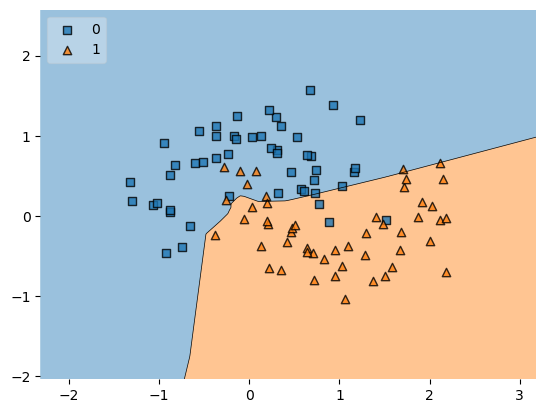

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [17]:
(np.random.randn(10,10)*0.01).min()

-0.027487284501910784

In [18]:
(np.random.randn(10,10)*0.01).max()

0.022396754714296405